In [ ]:
# import torch

# from config import ExperimentConfig
# from models import SimpleViTWithMoE

# cfg = ExperimentConfig()

# device = cfg.train.device or ("cuda" if torch.cuda.is_available() else "cpu")

# moe_params = {
#     "d_ff": cfg.moe.d_ff,
#     "num_experts": cfg.moe.num_experts,
#     "top_k": cfg.moe.top_k,
#     "gating_type": cfg.moe.gating_type,
# }

# model = SimpleViTWithMoE(
#     img_size=cfg.model.img_size,
#     patch_size=cfg.model.patch_size,
#     in_channels=cfg.model.in_channels,
#     embed_dim=cfg.model.embed_dim,
#     num_heads=cfg.model.num_heads,
#     num_classes=cfg.model.num_classes,
#     dropout=cfg.model.dropout,
#     use_moe=cfg.model.use_moe,
#     moe_params=moe_params,
# ).to(device)

# #print(model)
# print("Total params:", sum(p.numel() for p in model.parameters()))
# print("Device:", device)

Total params: 13182
Device: cpu


In [1]:
import json
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

from config import ExperimentConfig
from models import SimpleViTWithMoE
from utils.training import set_seed, get_device, train_one_epoch, evaluate, count_parameters
from utils.hessian import (
    compute_spectral_norms,
    compute_hessian_matrix,
    compute_ggn_matrix,
    get_params_by_prefix,
    get_param_names_by_prefix,
)
from utils.plotting import (
    apply_plot_style,
    save_rho_summary_plots,
    save_rho_inner_plot,
    save_hessian_table,
    plot_matrix_heatmap,
    ensure_dir,
)

In [2]:
cfg = ExperimentConfig()

# --- model ---
cfg.model.img_size = 28
cfg.model.patch_size = 14
cfg.model.in_channels = 1
cfg.model.embed_dim = 16
cfg.model.num_heads = 2
cfg.model.num_classes = 10
cfg.model.dropout = 0.1
cfg.model.use_moe = True

# --- moe ---
cfg.moe.num_experts = 4
cfg.moe.top_k = 2
cfg.moe.gating_type = "softmax"   # "softmax", "topk", "topk_no_renorm"
cfg.moe.d_ff = 64

# --- training ---
cfg.train.batch_size = 32
cfg.train.epochs = 5
cfg.train.lr = 1e-3
cfg.train.seed = 42
cfg.train.device = None
cfg.train.num_workers = 2

# --- hessian ---
cfg.hessian.save_interval_batch = 300
cfg.hessian.early_epochs = 1
cfg.hessian.power_iters = 100      # сначала лучше поменьше для быстрого теста
cfg.hessian.power_tol = 1e-6

# --- outputs ---
cfg.output.root_dir = "outputs"
cfg.output.run_name = "mnist_moe"

cfg

ExperimentConfig(model=ModelConfig(img_size=28, patch_size=14, in_channels=1, embed_dim=16, num_heads=2, num_classes=10, dropout=0.1, use_moe=True), moe=MoEConfig(num_experts=4, top_k=2, gating_type='softmax', d_ff=64), train=TrainConfig(batch_size=32, epochs=5, lr=0.001, seed=42, device=None, num_workers=2), hessian=HessianConfig(save_interval_batch=300, early_epochs=1, power_iters=100, power_tol=1e-06), output=OutputConfig(root_dir='outputs', run_name='mnist_moe'))

In [3]:
run_dir = Path(cfg.output.root_dir) / cfg.output.run_name
fig_dir = ensure_dir(run_dir / "figures")
table_dir = ensure_dir(run_dir / "tables")
json_dir = ensure_dir(run_dir / "json")
ckpt_dir = ensure_dir(run_dir / "checkpoints")
matrix_dir = ensure_dir(run_dir / "matrices")

print("Run dir:", run_dir)

Run dir: outputs\mnist_moe


In [4]:
set_seed(cfg.train.seed)
device = get_device(cfg.train.device)
apply_plot_style(font_size=14, use_tex=False)

print("Using device:", device)

Using device: cpu


In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.train.batch_size,
    shuffle=True,
    num_workers=cfg.train.num_workers,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.train.batch_size,
    shuffle=False,
    num_workers=cfg.train.num_workers,
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train size: 60000
Test size: 10000
Train batches: 1875
Test batches: 313


In [6]:
moe_params = {
    "d_ff": cfg.moe.d_ff,
    "num_experts": cfg.moe.num_experts,
    "top_k": cfg.moe.top_k,
    "gating_type": cfg.moe.gating_type,
}

model = SimpleViTWithMoE(
    img_size=cfg.model.img_size,
    patch_size=cfg.model.patch_size,
    in_channels=cfg.model.in_channels,
    embed_dim=cfg.model.embed_dim,
    num_heads=cfg.model.num_heads,
    num_classes=cfg.model.num_classes,
    dropout=cfg.model.dropout,
    use_moe=cfg.model.use_moe,
    moe_params=moe_params,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=cfg.train.lr)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=cfg.train.epochs * len(train_loader),
)

print(model)
print("Trainable params:", count_parameters(model))

SimpleViTWithMoE(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 16, kernel_size=(14, 14), stride=(14, 14))
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer): TransformerBlock(
    (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    (attn): SimpleSelfAttention(
      (q_proj): Linear(in_features=16, out_features=16, bias=True)
      (k_proj): Linear(in_features=16, out_features=16, bias=True)
      (v_proj): Linear(in_features=16, out_features=16, bias=True)
      (out_proj): Linear(in_features=16, out_features=16, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    (ff): MoELayer(
      (experts): ModuleList(
        (0-3): 4 x FFN(
          (fc1): Linear(in_features=16, out_features=64, bias=True)
          (act): ReLU()
          (fc2): Linear(in_features=64, out_features=16, bias=True)
        )
      )
      (router): Linear(in_features=16, out_features=4, bias=Tru

In [7]:
x0, y0 = next(iter(train_loader))
x0 = x0.to(device)
y0 = y0.to(device)

with torch.no_grad():
    logits0 = model(x0)

print("Input shape :", tuple(x0.shape))
print("Logits shape:", tuple(logits0.shape))
print("Target shape:", tuple(y0.shape))

Input shape : (32, 1, 28, 28)
Logits shape: (32, 10)
Target shape: (32,)


In [8]:
baseline_norms = compute_spectral_norms(
    model=model,
    x=x0,
    y=y0,
    loss_fn=criterion,
    params=None,
    num_iters=cfg.hessian.power_iters,
    tol=cfg.hessian.power_tol,
    device=device,
)

baseline_norms

{'H_norm': 41.10093688964844,
 'G_norm': 14.255844116210938,
 'rho': 0.34684961451088897,
 'num_params': 13182}

In [9]:
results = []
history = []

# фиксированный батч для измерения после эпох
eval_x, eval_y = next(iter(test_loader))
eval_x = eval_x.to(device)
eval_y = eval_y.to(device)

save_interval = cfg.hessian.save_interval_batch
early_epochs = cfg.hessian.early_epochs
power_iters = cfg.hessian.power_iters
power_tol = cfg.hessian.power_tol

for epoch in range(cfg.train.epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        total += y.size(0)
        correct += preds.eq(y).sum().item()

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch} | Batch {batch_idx}/{len(train_loader)} | loss={loss.item():.4f}")

        if epoch < early_epochs and batch_idx % save_interval == 0:
            print(f"Epoch {epoch}, batch {batch_idx}: computing full-model norms...")
            norms = compute_spectral_norms(
                model=model,
                x=x,
                y=y,
                loss_fn=criterion,
                params=None,
                num_iters=power_iters,
                tol=power_tol,
                device=device,
            )
            results.append({
                "epoch": epoch,
                "step": batch_idx,
                "scope": "full",
                **norms,
            })

    train_loss = running_loss / len(train_loader)
    train_acc = 100.0 * correct / total

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
    })

    norms = compute_spectral_norms(
        model=model,
        x=eval_x,
        y=eval_y,
        loss_fn=criterion,
        params=None,
        num_iters=power_iters,
        tol=power_tol,
        device=device,
    )
    results.append({
        "epoch": epoch,
        "step": -1,
        "scope": "full",
        **norms,
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.2f}% | "
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.2f}% | "
        f"H={norms['H_norm']:.3e}, G={norms['G_norm']:.3e}, rho={norms['rho']:.4f}"
    )

Epoch 0 | Batch 0/1875 | loss=2.3279
Epoch 0, batch 0: computing full-model norms...
Epoch 0 | Batch 100/1875 | loss=1.6617
Epoch 0 | Batch 200/1875 | loss=1.1739
Epoch 0 | Batch 300/1875 | loss=0.9888
Epoch 0, batch 300: computing full-model norms...
Epoch 0 | Batch 400/1875 | loss=1.2887
Epoch 0 | Batch 500/1875 | loss=0.7151
Epoch 0 | Batch 600/1875 | loss=0.9048
Epoch 0, batch 600: computing full-model norms...
Epoch 0 | Batch 700/1875 | loss=0.6942
Epoch 0 | Batch 800/1875 | loss=0.6734
Epoch 0 | Batch 900/1875 | loss=0.8038
Epoch 0, batch 900: computing full-model norms...
Epoch 0 | Batch 1000/1875 | loss=0.6642
Epoch 0 | Batch 1100/1875 | loss=0.7766
Epoch 0 | Batch 1200/1875 | loss=0.9845
Epoch 0, batch 1200: computing full-model norms...
Epoch 0 | Batch 1300/1875 | loss=1.0014
Epoch 0 | Batch 1400/1875 | loss=0.5448
Epoch 0 | Batch 1500/1875 | loss=0.7638
Epoch 0, batch 1500: computing full-model norms...
Epoch 0 | Batch 1600/1875 | loss=1.2087
Epoch 0 | Batch 1700/1875 | loss

In [10]:
with open(json_dir / "training_history.json", "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

with open(json_dir / "rho_results_full.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

torch.save(model.state_dict(), ckpt_dir / "model_final.pth")

print("Saved:")
print(json_dir / "training_history.json")
print(json_dir / "rho_results_full.json")
print(ckpt_dir / "model_final.pth")

Saved:
outputs\mnist_moe\json\training_history.json
outputs\mnist_moe\json\rho_results_full.json
outputs\mnist_moe\checkpoints\model_final.pth


In [11]:
save_rho_summary_plots(
    data=results,
    output_dir=fig_dir,
    prefix="rho_full",
    label="Full model",
)

save_rho_inner_plot(
    data=results,
    output_dir=fig_dir,
    filename="rho_full_inner",
    label="Full model",
)

save_hessian_table(results, table_dir / "hessian_table_full.txt")

print("Plots and table saved.")

Plots and table saved.


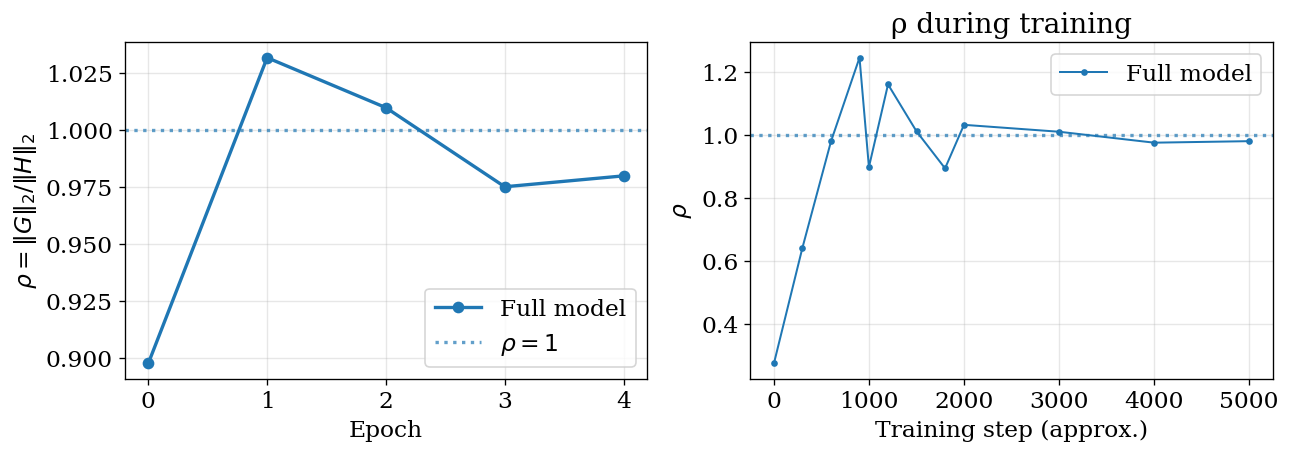

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

from utils.plotting import plot_rho_vs_epoch, plot_rho_vs_step

plot_rho_vs_epoch(results, ax=axes[0], label="Full model")
plot_rho_vs_step(results, ax=axes[1], label="Full model")

plt.tight_layout()
plt.show()

In [13]:
moe_prefix = "transformer.ff"

moe_param_names = get_param_names_by_prefix(model, moe_prefix)
moe_params_only = get_params_by_prefix(model, moe_prefix)

print("Number of MoE parameter tensors:", len(moe_params_only))
print("First few parameter names:")
for name in moe_param_names[:10]:
    print(" ", name)

Number of MoE parameter tensors: 18
First few parameter names:
  transformer.ff.experts.0.fc1.weight
  transformer.ff.experts.0.fc1.bias
  transformer.ff.experts.0.fc2.weight
  transformer.ff.experts.0.fc2.bias
  transformer.ff.experts.1.fc1.weight
  transformer.ff.experts.1.fc1.bias
  transformer.ff.experts.1.fc2.weight
  transformer.ff.experts.1.fc2.bias
  transformer.ff.experts.2.fc1.weight
  transformer.ff.experts.2.fc1.bias


In [14]:
moe_norms = compute_spectral_norms(
    model=model,
    x=eval_x,
    y=eval_y,
    loss_fn=criterion,
    params=moe_params_only,
    num_iters=cfg.hessian.power_iters,
    tol=cfg.hessian.power_tol,
    device=device,
)

moe_norms

{'H_norm': 0.7564905881881714,
 'G_norm': 0.5570947527885437,
 'rho': 0.7364199389748,
 'num_params': 8580}

In [15]:
full_norms = compute_spectral_norms(
    model=model,
    x=eval_x,
    y=eval_y,
    loss_fn=criterion,
    params=None,
    num_iters=cfg.hessian.power_iters,
    tol=cfg.hessian.power_tol,
    device=device,
)

comparison = {
    "full_H": full_norms["H_norm"],
    "full_G": full_norms["G_norm"],
    "full_rho": full_norms["rho"],
    "moe_H": moe_norms["H_norm"],
    "moe_G": moe_norms["G_norm"],
    "moe_rho": moe_norms["rho"],
    "G_ratio_moe_to_full": moe_norms["G_norm"] / full_norms["G_norm"] if full_norms["G_norm"] > 0 else None,
}

comparison

{'full_H': 49.87344741821289,
 'full_G': 48.875736236572266,
 'full_rho': 0.9799951430412593,
 'moe_H': 0.7564905881881714,
 'moe_G': 0.5570947527885437,
 'moe_rho': 0.7364199389748,
 'G_ratio_moe_to_full': 0.011398186414871562}

In [16]:
H_moe = compute_hessian_matrix(
    model=model,
    x=eval_x,
    y=eval_y,
    loss_fn=criterion,
    params=moe_params_only,
    device=device,
)

print("H_moe shape:", tuple(H_moe.shape))

H_moe shape: (8580, 8580)


In [17]:
# Для первой heatmap берём не весь MoE, а малый блок:
# router + expert 0
small_prefixes = [
    "transformer.ff.router",
    "transformer.ff.experts.0",
]

small_named_params = []
for name, p in model.named_parameters():
    if p.requires_grad and any(name.startswith(pref) for pref in small_prefixes):
        small_named_params.append((name, p))

small_param_names = [name for name, _ in small_named_params]
small_params = [p for _, p in small_named_params]
small_block_sizes = [p.numel() for _, p in small_named_params]

print("Small block parameter tensors:", len(small_params))
print("Small block total dim:", sum(small_block_sizes))
for name, size in zip(small_param_names, small_block_sizes):
    print(f"{name:45s} | {size}")

Small block parameter tensors: 6
Small block total dim: 2196
transformer.ff.experts.0.fc1.weight           | 1024
transformer.ff.experts.0.fc1.bias             | 64
transformer.ff.experts.0.fc2.weight           | 1024
transformer.ff.experts.0.fc2.bias             | 16
transformer.ff.router.weight                  | 64
transformer.ff.router.bias                    | 4


In [18]:
H_small = compute_hessian_matrix(
    model=model,
    x=eval_x,
    y=eval_y,
    loss_fn=criterion,
    params=small_params,
    device=device,
    dtype=torch.float32,
    chunk_size=64,
    store_on_cpu=True,
)

print("H_small shape:", tuple(H_small.shape))

H_small shape: (2196, 2196)


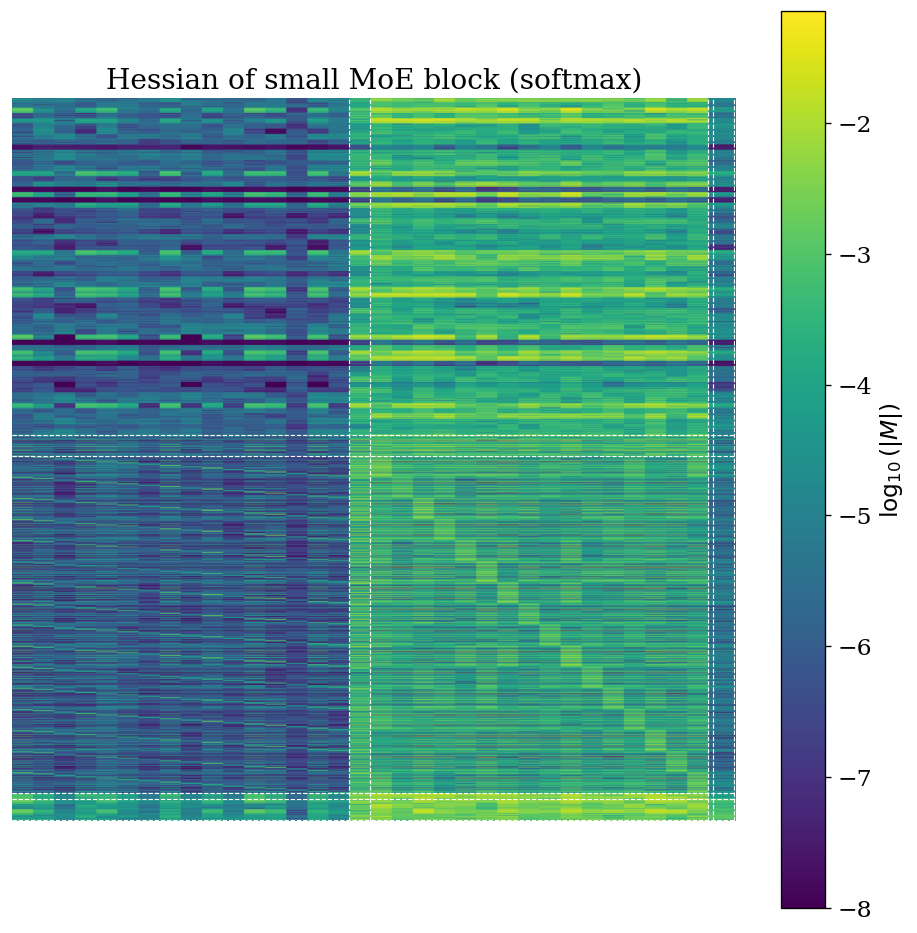

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))

plot_matrix_heatmap(
    H_small,
    ax=ax,
    title=f"Hessian of small MoE block ({cfg.moe.gating_type})",
    log_abs=True,
    block_sizes=small_block_sizes,
)

plt.tight_layout()
plt.show()

fig.savefig(matrix_dir / "hessian_small_block.pdf", bbox_inches="tight")
fig.savefig(matrix_dir / "hessian_small_block.png", dpi=150, bbox_inches="tight")

In [20]:
G_small = compute_ggn_matrix(
    model=model,
    x=eval_x,
    y=eval_y,
    loss_fn=criterion,
    params=small_params,
    device=device,
    dtype=torch.float32,
    chunk_size=64,
    store_on_cpu=True,
)

print("G_small shape:", tuple(G_small.shape))

G_small shape: (2196, 2196)


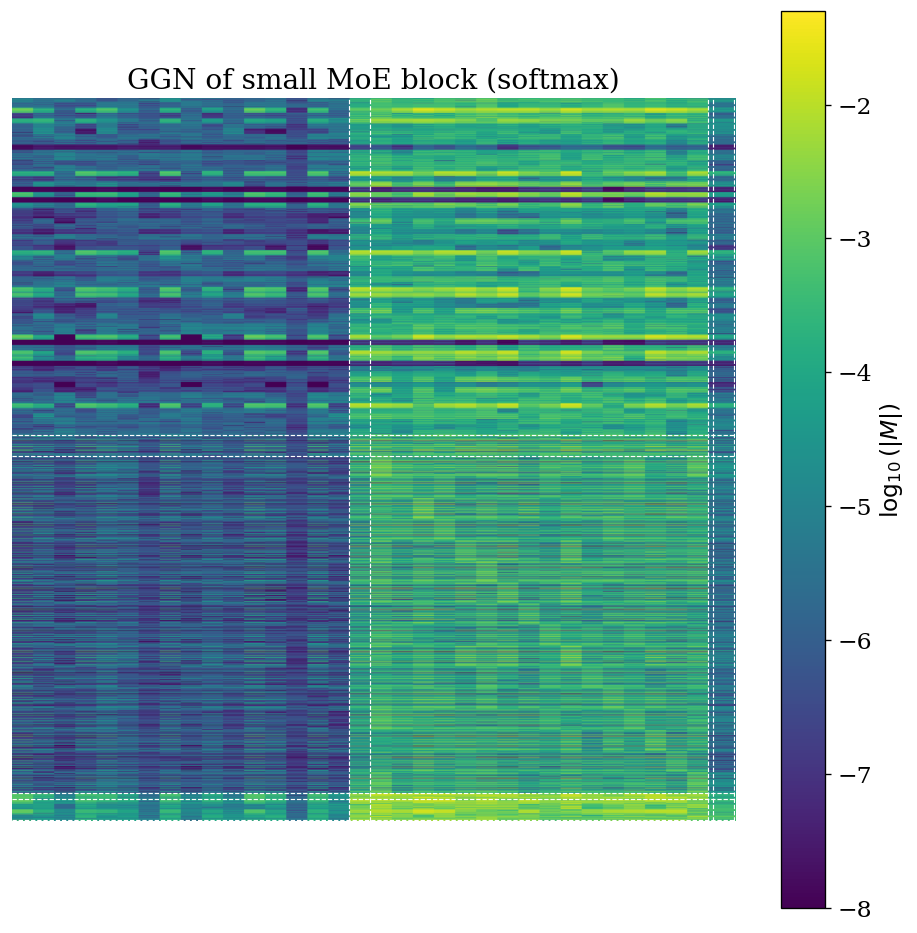

In [21]:
fig, ax = plt.subplots(figsize=(8, 8))

plot_matrix_heatmap(
    G_small,
    ax=ax,
    title=f"GGN of small MoE block ({cfg.moe.gating_type})",
    log_abs=True,
    block_sizes=small_block_sizes,
)

plt.tight_layout()
plt.show()

fig.savefig(matrix_dir / "ggn_small_block.pdf", bbox_inches="tight")
fig.savefig(matrix_dir / "ggn_small_block.png", dpi=150, bbox_inches="tight")

In [22]:
# Осторожно: это уже заметно тяжелее
# Запускайте только если малый блок уже успешно посчитался

full_moe_dim = sum(p.numel() for p in moe_params_only)
print("Full MoE dim:", full_moe_dim)

H_moe = compute_hessian_matrix(
    model=model,
    x=eval_x,
    y=eval_y,
    loss_fn=criterion,
    params=moe_params_only,
    device=device,
    dtype=torch.float32,
    chunk_size=32,      # меньше -> безопаснее по памяти
    store_on_cpu=True,
)

print("H_moe shape:", tuple(H_moe.shape))

Full MoE dim: 8580
H_moe shape: (8580, 8580)


In [24]:
full_named_params = [
    (name, p)
    for name, p in model.named_parameters()
    if name.startswith(moe_prefix) and p.requires_grad
]

full_block_names = [name for name, _ in full_named_params]
full_block_sizes = [p.numel() for _, p in full_named_params]

print("Full MoE parameter tensors:", len(full_block_sizes))
print("Full MoE total dim:", sum(full_block_sizes))
for name, size in zip(full_block_names, full_block_sizes):
    print(f"{name:45s} | {size}")

Full MoE parameter tensors: 18
Full MoE total dim: 8580
transformer.ff.experts.0.fc1.weight           | 1024
transformer.ff.experts.0.fc1.bias             | 64
transformer.ff.experts.0.fc2.weight           | 1024
transformer.ff.experts.0.fc2.bias             | 16
transformer.ff.experts.1.fc1.weight           | 1024
transformer.ff.experts.1.fc1.bias             | 64
transformer.ff.experts.1.fc2.weight           | 1024
transformer.ff.experts.1.fc2.bias             | 16
transformer.ff.experts.2.fc1.weight           | 1024
transformer.ff.experts.2.fc1.bias             | 64
transformer.ff.experts.2.fc2.weight           | 1024
transformer.ff.experts.2.fc2.bias             | 16
transformer.ff.experts.3.fc1.weight           | 1024
transformer.ff.experts.3.fc1.bias             | 64
transformer.ff.experts.3.fc2.weight           | 1024
transformer.ff.experts.3.fc2.bias             | 16
transformer.ff.router.weight                  | 64
transformer.ff.router.bias                    | 4


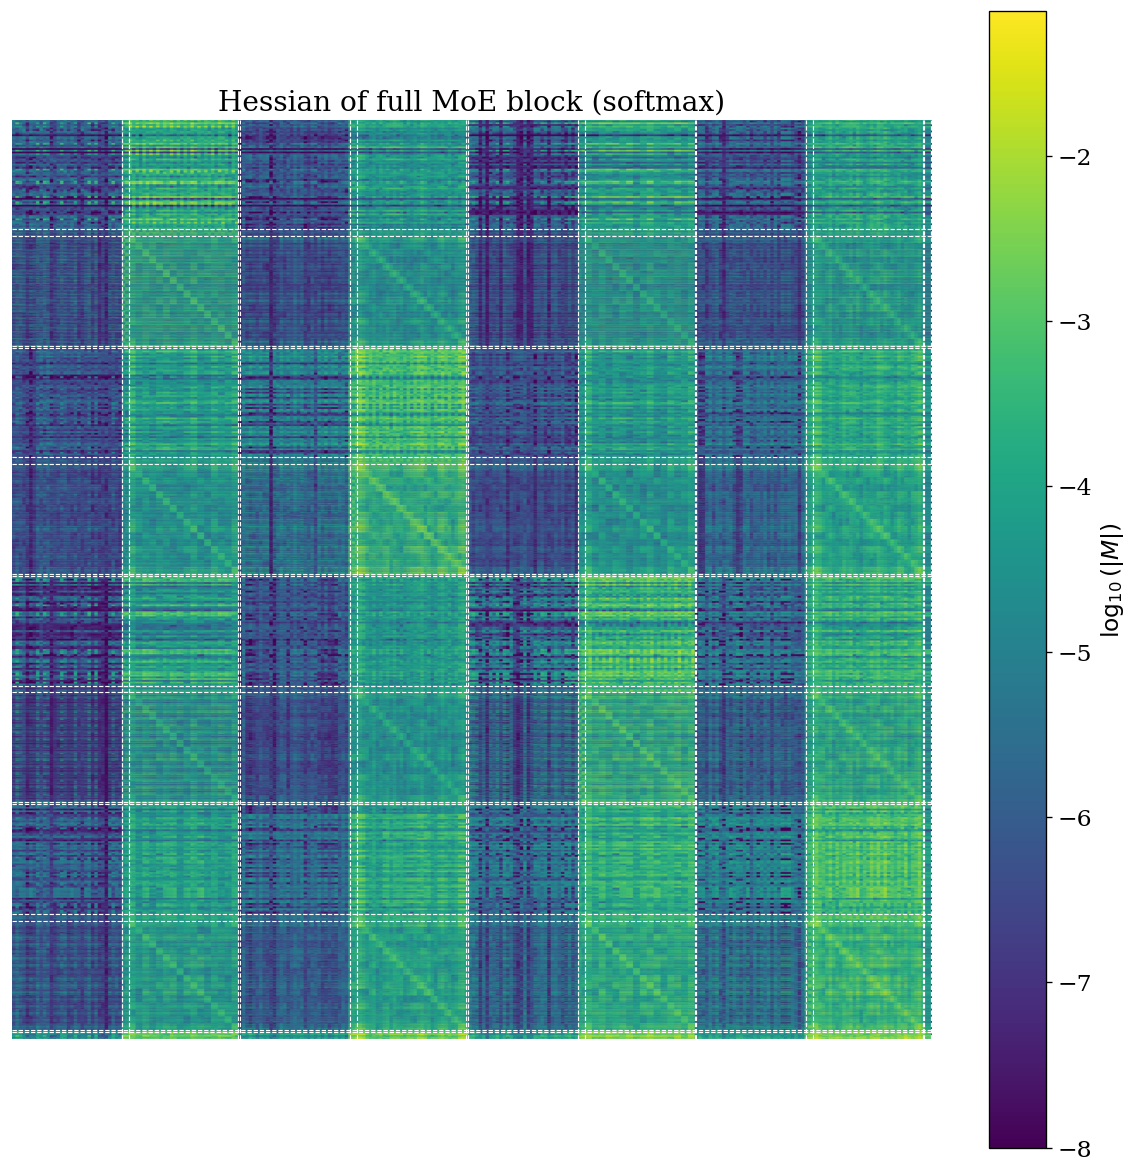

In [25]:
fig, ax = plt.subplots(figsize=(10, 10))

plot_matrix_heatmap(
    H_moe,
    ax=ax,
    title=f"Hessian of full MoE block ({cfg.moe.gating_type})",
    log_abs=True,
    block_sizes=full_block_sizes,
)

plt.tight_layout()
plt.show()

fig.savefig(matrix_dir / "hessian_full_moe_block.pdf", bbox_inches="tight")
fig.savefig(matrix_dir / "hessian_full_moe_block.png", dpi=150, bbox_inches="tight")

In [26]:
G_moe = compute_ggn_matrix(
    model=model,
    x=eval_x,
    y=eval_y,
    loss_fn=criterion,
    params=moe_params_only,
    device=device,
    dtype=torch.float32,
    chunk_size=32,
    store_on_cpu=True,
)

print("G_moe shape:", tuple(G_moe.shape))

G_moe shape: (8580, 8580)


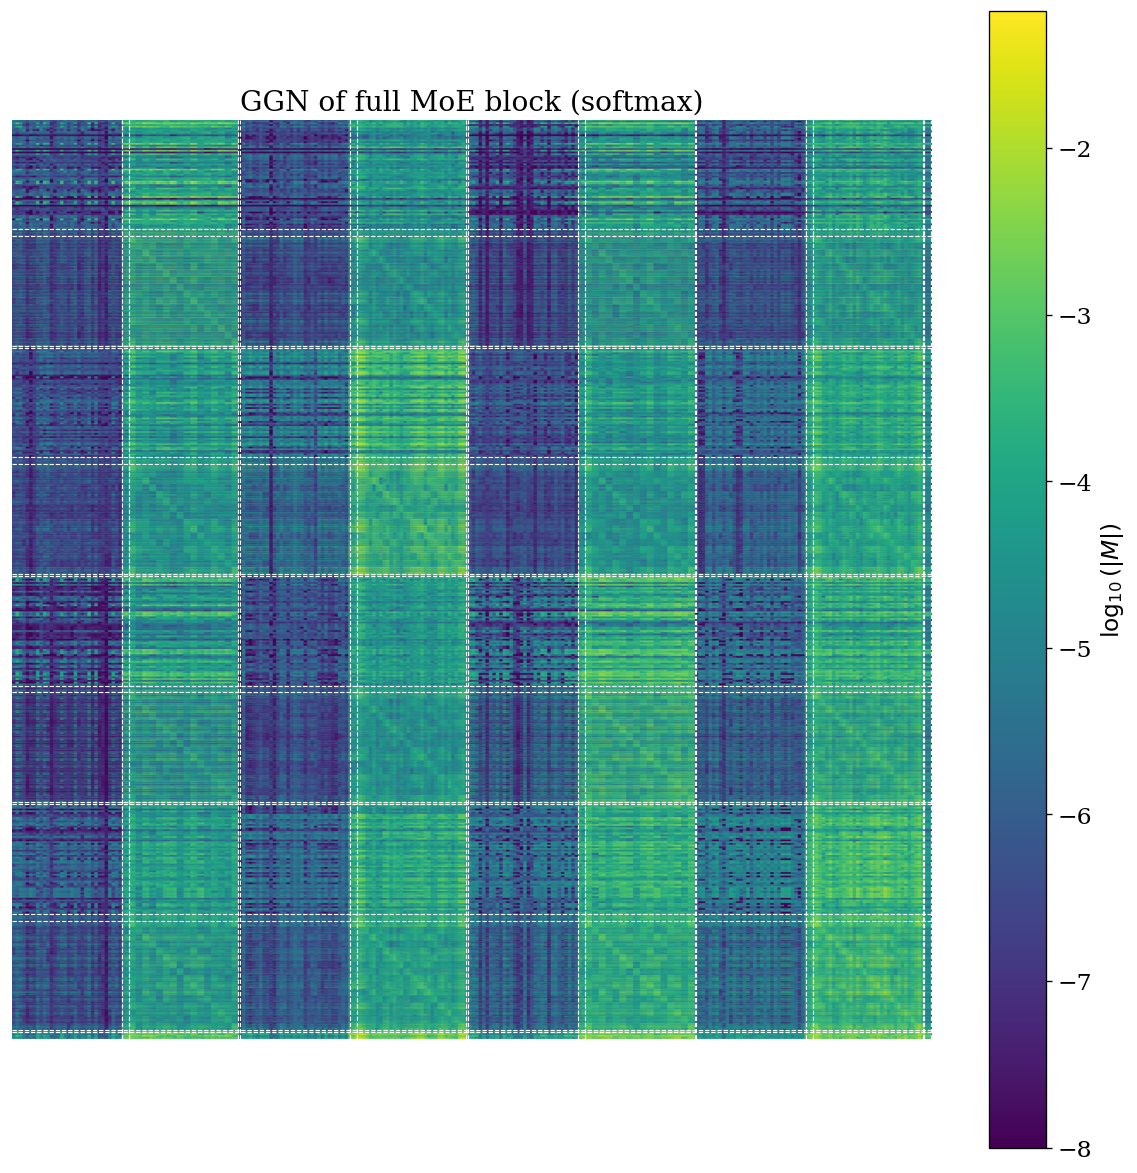

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))

plot_matrix_heatmap(
    G_moe,
    ax=ax,
    title=f"GGN of full MoE block ({cfg.moe.gating_type})",
    log_abs=True,
    block_sizes=full_block_sizes,
)

plt.tight_layout()
plt.show()

fig.savefig(matrix_dir / "ggn_full_moe_block.pdf", bbox_inches="tight")
fig.savefig(matrix_dir / "ggn_full_moe_block.png", dpi=150, bbox_inches="tight")